In [44]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.core.pylabtools import figsize

Моим направлением для анализа явялется сезонность и сегменты пользователей.
Так что даайте начнем с анализа целевой переменной, за затем посмотрим распределения типов пользователей

Text(0, 0.5, 'Количество пользователей')

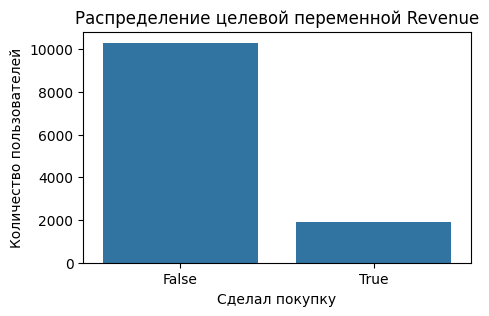

In [54]:
figsize(5, 3)

sns.countplot(data=data, x='Revenue')
plt.title('Распределение целевой переменной Revenue')
plt.xlabel('Сделал покупку')
plt.ylabel('Количество пользователей')

Видим, что большинство сессий посетителей не заканчиваются покупкой на сайте, то есть видим явный дисбаланс классов, что будет влиять в дальнейшем на наш анализ

Text(0.5, 1.0, 'Распределение типов посетителей')

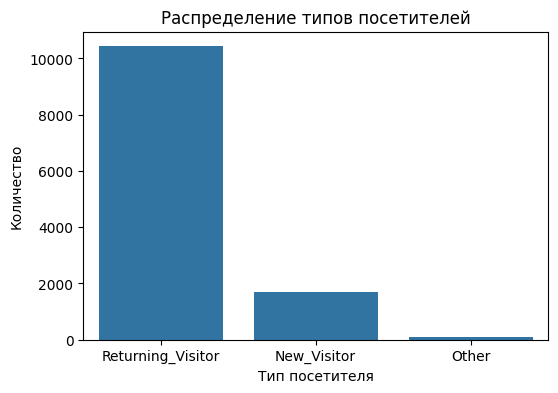

In [55]:
figsize(6,4)

sns.countplot(data=data, x='VisitorType')

plt.xlabel('Тип посетителя')
plt.ylabel('Количество')
plt.title('Распределение типов посетителей')

Исходя из графика можем прийти к выводу, что большей частью посетителей являются вернувшиеся пользователи — они и формруют основной поток магазина

In [56]:
visit_rev = data.groupby('VisitorType')['Revenue'].mean()*100
visit_rev

,Revenue
VisitorType,
New_Visitor,24.926167
Other,19.753086
Returning_Visitor,14.092609


Text(0.5, 1.0, 'Конверсия по типу посетителя')

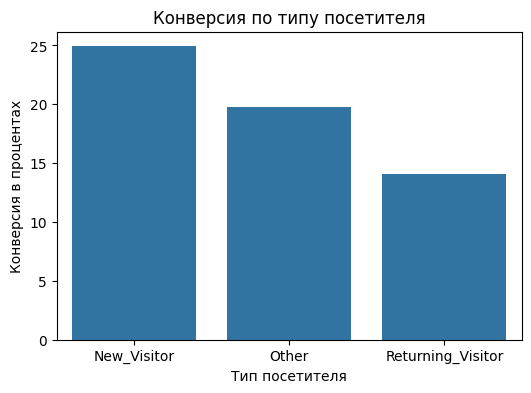

In [57]:
figsize(6,4)

sns.barplot(
    x= visit_rev.index,
    y = visit_rev.values
)

plt.xlabel('Тип посетителя')
plt.ylabel('Конверсия в процентах')
plt.title('Конверсия по типу посетителя')

Можем прийти к выводу, что именно новые посетители чаще совершают покупки на сайте, чем те, которые возвращаются к нашему сайту вновь. Что касается группы other мы не можем делать какие-то выводы, так как из предыдущего графика выявили, что количество таких наблюдений предельно мало

Перейдем к анализу поведения пользователей в зависимости от сезона

In [58]:
month = data['Month'].unique()
month

array(['Feb', 'Mar', 'May', 'Oct', 'June', 'Jul', 'Aug', 'Nov', 'Sep',
       'Dec'], dtype=object)

Text(0.5, 1.0, 'Количество пользователей по месяцам')

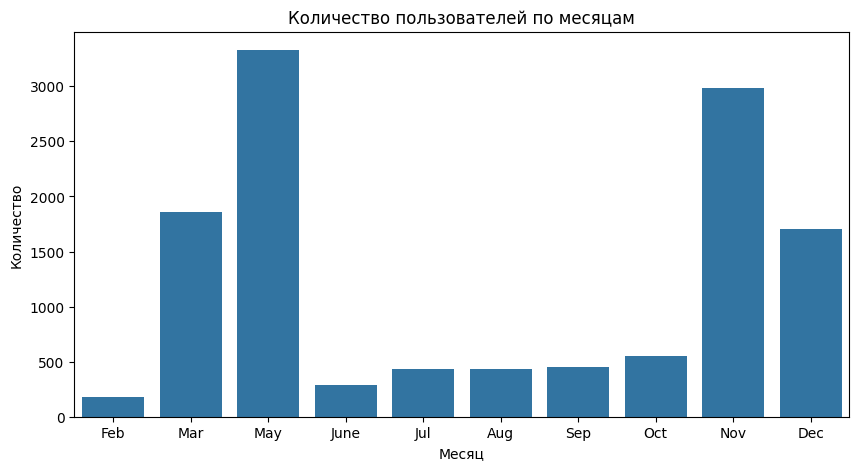

In [59]:
months = ['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

figsize(10, 5)
sns.countplot(data=data, x='Month', order=months)
plt.xlabel('Месяц')
plt.ylabel('Количество')
plt.title('Количество пользователей по месяцам')

Чаще всего наш сайт посещают пользователи в марте, мае, ноябре и декабре

In [60]:
months_rev=data.groupby('Month')['Revenue'].mean()*100
months_rev=months_rev.reindex(months)
months_rev

,Revenue
Month,
Feb,1.657459
Mar,10.322581
May,10.964254
June,10.175439
Jul,15.277778
Aug,17.551963
Sep,19.196429
Oct,20.947177
Nov,25.486251


Text(0.5, 1.0, 'Конверсия по месяцам')

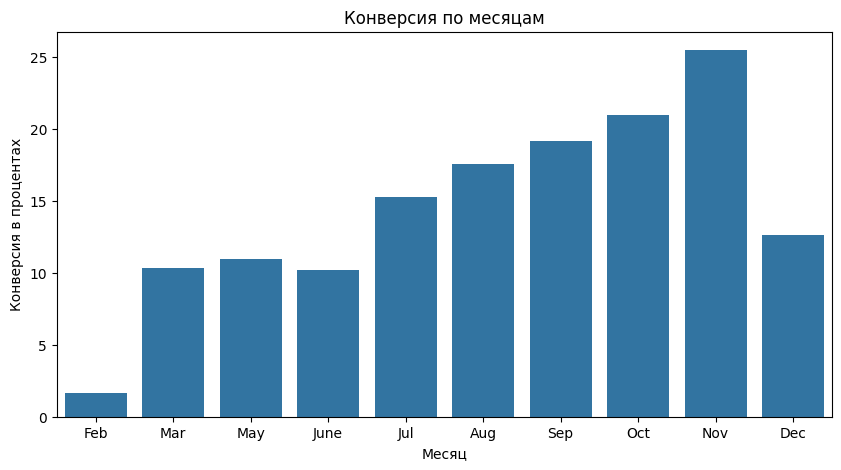

In [61]:
figsize(10, 5)

sns.barplot(
    x=months_rev.index,
    y=months_rev.values
)

plt.xlabel('Месяц')
plt.ylabel('Конверсия в процентах')
plt.title('Конверсия по месяцам')

Можем заметить, что самая высокая конверсия у нас осенью, особенно в ноябре. А вот в февраля конверсия очень низкая

Text(45.722222222222214, 0.5, 'Месяц')

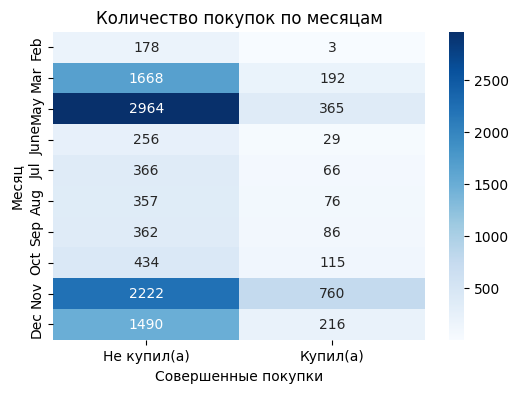

In [62]:
help_data = pd.crosstab(data['Month'], data['Revenue'])
help_data=help_data.reindex(months)

figsize(6, 4)
sns.heatmap(help_data, annot=True, fmt='d', cmap='Blues')
plt.title('Количество покупок по месяцам')
plt.xticks([0.5, 1.5], ['Не купил(а)', 'Купил(а)'])
plt.xlabel('Совершенные покупки')
plt.ylabel('Месяц')

https://pandas.pydata.org/docs/reference/api/pandas.crosstab.html$0 - доп. источник

В месяцах с самой большой активностью на сайте и было произведено наибольшее количество покупок относительно других месяцев

Text(0, 0.5, 'Количество пользователей')

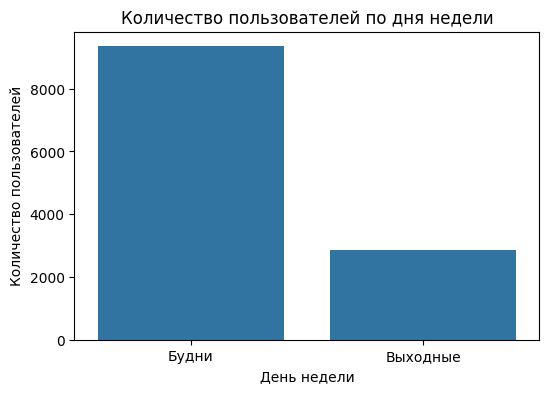

In [63]:
sns.countplot(x='Weekend', data=data)

plt.title('Количество пользователей по дня недели')
plt.xticks([0, 1], ['Будни', 'Выходные'])
plt.xlabel('День недели')
plt.ylabel('Количество пользователей')

Видим, что большая чать посетителей заходят на сайт имено в будни дни.

In [64]:
weekend_rev = data.groupby('Weekend', as_index=False)['Revenue'].mean()
weekend_rev['Revenue'] =weekend_rev['Revenue']*100
weekend_rev

,Weekend,Revenue
0,False,15.075968
1,True,17.453655


Text(0, 0.5, 'Конверсия в процентах')

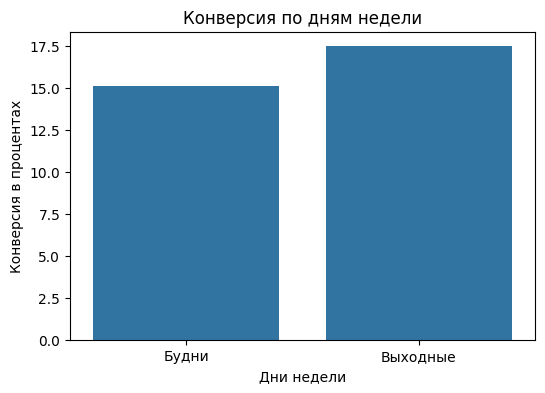

In [65]:
sns.barplot(x='Weekend', y='Revenue', data=weekend_rev)

plt.title('Конверсия по дням недели')
plt.xlabel('Дни недели')
plt.xticks([0, 1], ['Будни', 'Выходные'])
plt.ylabel('Конверсия в процентах')

In [66]:
act_month = data.groupby(['Month', 'VisitorType'])['Revenue'].mean()*100
act_month = act_month.unstack('VisitorType')
act_month = act_month.reindex(months)

Интересное наблюдение относительно предыдущего графика, что покупают все-таки чаще именно в выходные дни, а сидят на сайте чаще в будни

Text(45.722222222222214, 0.5, 'Месяц')

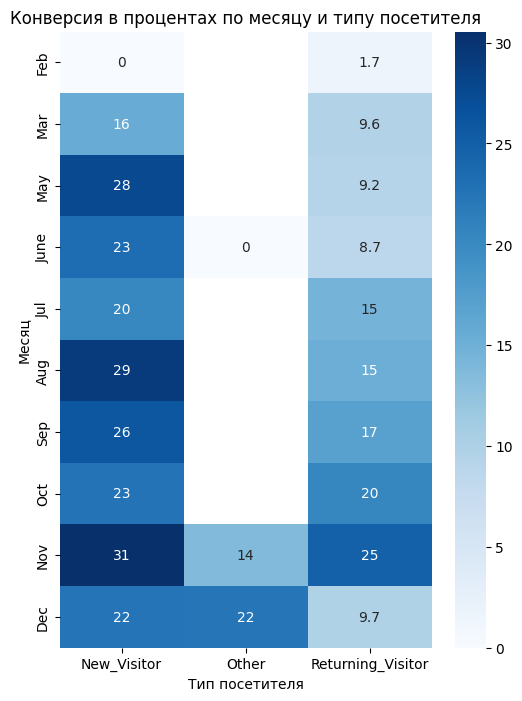

In [67]:
figsize(6,8)
sns.heatmap(act_month, annot=True, cmap='Blues')
plt.title('Конверсия в процентах по месяцу и типу посетителя')
plt.xlabel('Тип посетителя')
plt.ylabel('Месяц')

Наиболее высокую конверсию практически во всех месяцах показывают новые посетители. Особенно можем подметить месяц - ноябрь, где конверсия максимальна сразу для нескольких типов пользователей

Анализ конверсии по типу посетителя показал большие различия. Новые посетители совершают покупки намного чаще чем, вернувшиеся пользователи, что вообще интуитивно непонятно, ведь чаще всего многие плюшки в бизнесах отдаются именно возвращающимся людям. Именно поэтому проверим это статистически

Зависит ли тип посетителя от факта совершения покупки или нет. Так как обе переменые , а именно типо посетителя и факт покупки, являются категориальными, то для проверки связи будем использовать хи-квадрат.

Гипотезы:

H0 - тип посетителя не влияет на вероятность покупки

H1 - тип посетителя влияет на вероятность покупки

In [68]:
from scipy.stats import chi2_contingency

t = pd.crosstab(data['VisitorType'], data['Revenue'])
chi2, p_value, dof, expected = chi2_contingency(t)

print('chi2:', chi2)
print('p_value:', p_value)
print('degrees of freedom:', dof)

chi2: 130.66762667570268
p_value: 4.2255708283129954e-29
degrees of freedom: 2


P-value < 0.05, следовательно мы отклоняем нулевую гипотезу о том, что тип посетителя не влияет на вероятность покупки и принимаем альтернативную гипотезу о том, что тип посетителя влияет на вероятность покупки.

**Выводы:** Новые посетители покупают намного лучше, вернувшихся. Можем предположить, что новые клиенты приходят конкретно за покупкой чего-либо, а вот возращающиеся пользователи возможно просто изучают каталог, ждут каких-то скидок/акций, то есть изучают сайт и откладывают покупку.
Можно пореккомендовать интернет-магазину привлекать к покупке вернувшихся пользователей персональными скидками и напоминаниями о предыдущих просмотрах

Конверсия по месяцам показала нам тенденцию к сезонности, особенно часто люди заходящие на сайт, совершали покупку именно в осенний период, обратно как в зимний и весенний периоды показатели были снижены. Проверим, является ли зависимость конверсии от месяца статистически значимой

Посмотрим, зависит ли факт покупки от месяца. Аналогично и предыдущему пункту воспоьзуемся хи-квадратом, так как обе переменных являются категореальными.

Гипотезы:

H0 - факт покупки не зависит от месяца

H1 - факт покупки зависит от месяца


In [69]:
from scipy.stats import chi2_contingency

t = pd.crosstab(data['Month'], data['Revenue'])
chi2, p_value, dof, expected = chi2_contingency(t)

print('chi2:', chi2)
print('p_value:', p_value)
print('degrees of freedom:', dof)

chi2: 376.27981735309487
p_value: 1.566845182122921e-75
degrees of freedom: 9


P-value < 0.05 - мы отклоняем нулевую гипотезу о том, что факт покупки не зависит от месяца и принимаем альтернативную гипотезу о том, что факт покупки зависит от месяца

**Выводы:** Конверсия неравномерна в течение года. Пик приходится на ноябрь, что может говорить о распродажах, таких как черная пятница или киберпонедельник. А вот к декабрю покупок становится значительно меньше, думаю дело в том, бюджет посетителей заметно подсокращается после распродаж.
Касаемо советов для бизнеса, скорее всего следует более активно запускать рекламные кампании имено осенью, а в несезон заниматься удержанием клиентсокй базы

**Наблюдение из EDA:** barplot конверсии показал различие — в выходные около 17 процентов против около 15 процентов в будни. Разница визуально присутствует,
но требует проверки - возможно, она объясняется случайным разбросом.

Проверим, чаще ли покупают в выходные, чем в будни. Используем z-тест для пропорций, потому что мы сравниваем доли покупок в двух независимых группах и выборки достаточно большие

Гипотезы:

H0 - конверсия в выходные не отличается от конверсии в будни

H1 - конверсия в выходные дни выше, чем в будни

In [70]:
from statsmodels.stats.proportion import proportions_ztest

weekend=data[data['Weekend'] ==True]['Revenue']
day=data[data['Weekend'] == False]['Revenue']

c = [weekend.sum(), day.sum()]
nb = [len(weekend), len(day)]
stat, p = proportions_ztest(c, nb)

print('z-statistic:', stat)
print('p-value:', p)

z-statistic: 3.0633665249074817
p-value: 0.0021886181520724833


https://www.statsmodels.org/dev/generated/statsmodels.stats.proportion.proportions_ztest.html$0 - доп. источник

P-value < 0.05 - мы отклоняем нулевую гипотезу о том, что конверсия в выходные не отличается от конверсии в будни и принимаем альтернативную гипотезу о том, что конверсия в выходные выше, чем в будни

**Выводы:** несмотря на статистическую значимость, разница не настолько велика, чтобы строить какие-то бизнес стратегии, однако можно перенести часть уведомлений для пользователей и акции к выходным, это может показать положительную динамику в покупках